# EdgeVisionAI — Time Series Comparison: SNPE vs PSNPE vs QNN

This notebook loads the three inference logs, aligns their timestamps to a
**common (intersection) per-second timeline**, skips the first 5 warm-up
seconds of each recording, and produces five individual time-series plots:

- CPU Usage (%)
- Memory Usage (MB)
- FPS
- Model Inference latency (ms)
- Total Inference latency (ms)

## 1. Imports & Global Configuration

In [1]:
import glob
import re

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# ---------------------------------------------------------------------------
# Global color palette — change these to customise all plots at once
# ---------------------------------------------------------------------------
COLORS = {
    "SNPE":  "#2580B7",  # blue
    "PSNPE": "#F59B11",  # orange
    "QNN":   "#179E86",  # green
}

# Figure aesthetics
FIGURE_WIDTH   = 14
SUBPLOT_HEIGHT = 3   # height per subplot row
LINE_WIDTH     = 1.5
ALPHA          = 0.85

## 2. Load CSV Files

In [2]:
def load_csv(path: str) -> pd.DataFrame:
    """Load an EdgeVisionAI log CSV and parse the timestamp column."""
    df = pd.read_csv(path, parse_dates=["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)
    return df


def detect_framework(path: str) -> str:
    """Extract the framework name (SNPE / PSNPE / QNN) from the file name."""
    match = re.search(r"EdgeVisionAI-([A-Z]+)_log", path)
    if match:
        return match.group(1)
    raise ValueError(f"Cannot detect framework name from: {path}")


# Discover all log files in the same directory as the notebook
csv_paths = sorted(glob.glob("logs/EdgeVisionAI-*_log_*.csv"))
print(f"Found {len(csv_paths)} CSV file(s):")
for p in csv_paths:
    print(f"  {p}")

raw_data: dict[str, pd.DataFrame] = {}
for path in csv_paths:
    name = detect_framework(path)
    raw_data[name] = load_csv(path)
    print(f"  {name}: {len(raw_data[name])} rows, "
          f"{raw_data[name]['timestamp'].min()} → {raw_data[name]['timestamp'].max()}")

Found 3 CSV file(s):
  logs/EdgeVisionAI-PSNPE_log_2026-05-27_19-17-48.csv
  logs/EdgeVisionAI-QNN_log_2026-05-27_19-43-06.csv
  logs/EdgeVisionAI-SNPE_log_2026-05-27_19-17-02.csv
  PSNPE: 129128 rows, 2026-05-27 19:17:49.342000 → 2026-05-29 09:34:36.934000
  QNN: 129195 rows, 2026-05-27 19:43:07.390000 → 2026-05-29 09:30:36.589000
  SNPE: 130329 rows, 2026-05-27 19:17:03.318000 → 2026-05-29 09:33:44.915000


## 3. Resample to Per-Second Buckets

Multiple rows can fall within the same wall-clock second (the sensor samples at ~1 Hz but with sub-second jitter).  
We floor each timestamp to the second and take the **mean** of all rows that land in the same bucket.

In [3]:
METRICS = ["cpu_pct", "memory_mb", "fps", "inference_ms", "total_ms"]


def resample_to_seconds(df: pd.DataFrame) -> pd.DataFrame:
    """Floor timestamps to the nearest second and average within each bucket."""
    df = df.copy()
    df["second"] = df["timestamp"].dt.floor("s")
    return df.groupby("second")[METRICS].mean()


resampled: dict[str, pd.DataFrame] = {
    name: resample_to_seconds(df) for name, df in raw_data.items()
}

for name, df in resampled.items():
    print(f"{name}: {len(df)} second-buckets")

PSNPE: 129126 second-buckets
QNN: 129193 second-buckets
SNPE: 130325 second-buckets


## 4. Trim Warm-Up Seconds & Build Intersection Timeline

**Warm-up trim:** the first 5 seconds of each recording are dropped before
any alignment step.

**Intersection:** only the seconds that are present in **all three** datasets
are kept, so the x-axis covers the common recording window only.

The x-axis is expressed as **relative seconds** from the start of the intersection.

In [4]:
WARMUP_SECONDS = 5  # drop this many seconds from the start of each recording

def trim_warmup(df: pd.DataFrame, seconds: int) -> pd.DataFrame:
    """Drop the first N seconds from a per-second-indexed DataFrame."""
    cutoff = df.index.min() + pd.Timedelta(seconds=seconds)
    return df[df.index > cutoff]


trimmed: dict[str, pd.DataFrame] = {
    name: trim_warmup(df, WARMUP_SECONDS) for name, df in resampled.items()
}

# Intersection: only seconds present in ALL datasets
intersection_index = trimmed[list(trimmed.keys())[0]].index
for df in list(trimmed.values())[1:]:
    intersection_index = intersection_index.intersection(df.index)

t0 = intersection_index.min()  # reference zero point
relative_seconds = (intersection_index - t0).total_seconds()

print(f"Intersection spans {relative_seconds[-1]:.0f} s  ({len(intersection_index)} second-buckets)")
print(f"Common window: {t0}  →  {intersection_index.max()}")

# Slice each dataset to the intersection
aligned: dict[str, pd.DataFrame] = {
    name: df.reindex(intersection_index) for name, df in trimmed.items()
}

Intersection spans 136043 s  (114521 second-buckets)
Common window: 2026-05-27 19:43:13  →  2026-05-29 09:30:36


## 5. Individual Time Series Plots

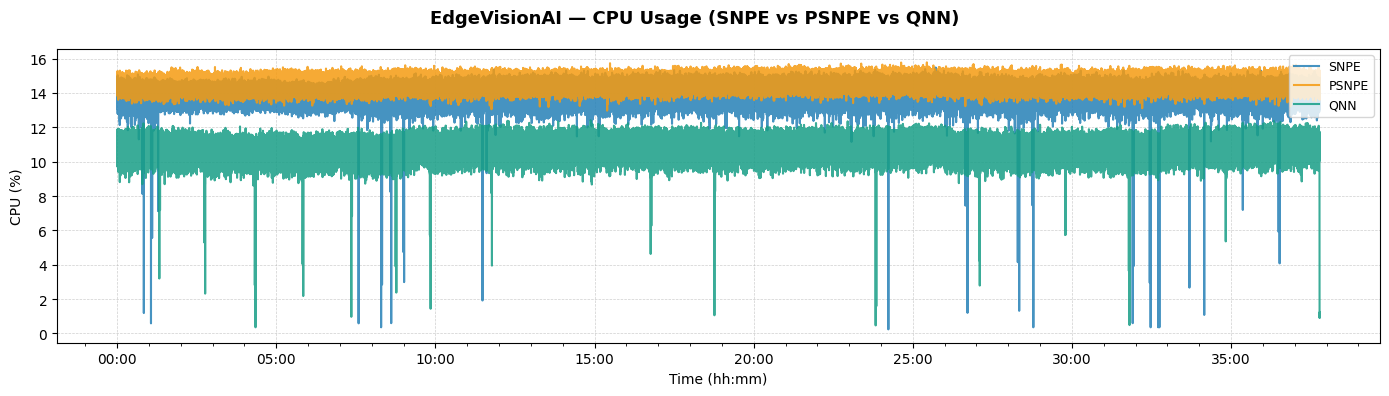

Saved → plots/time_series_cpu_pct.png


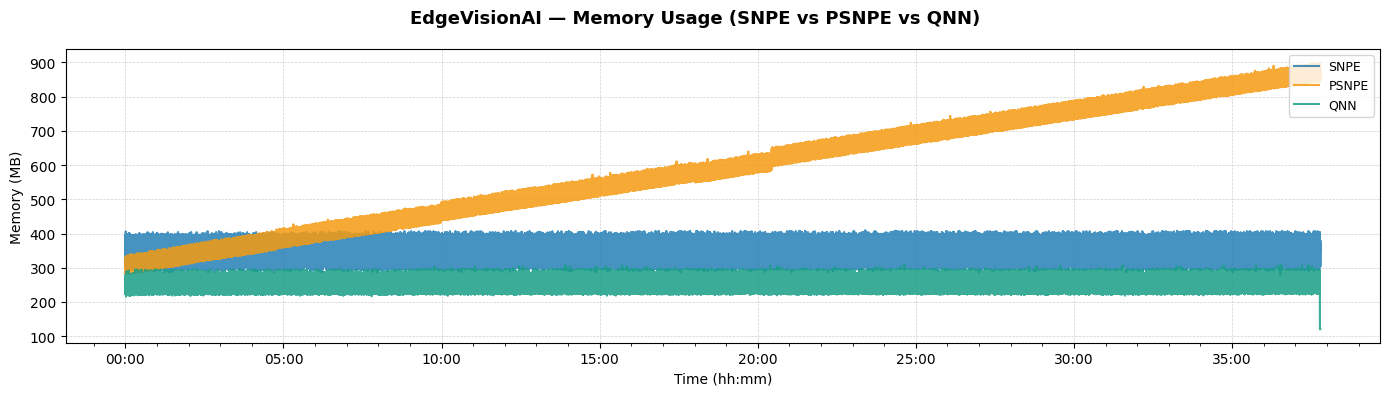

Saved → plots/time_series_memory_mb.png


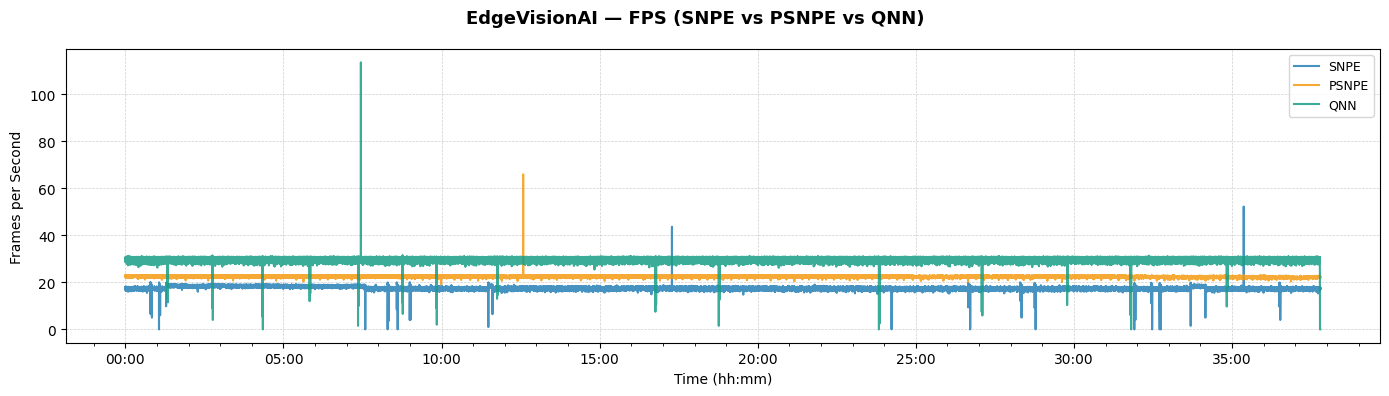

Saved → plots/time_series_fps.png


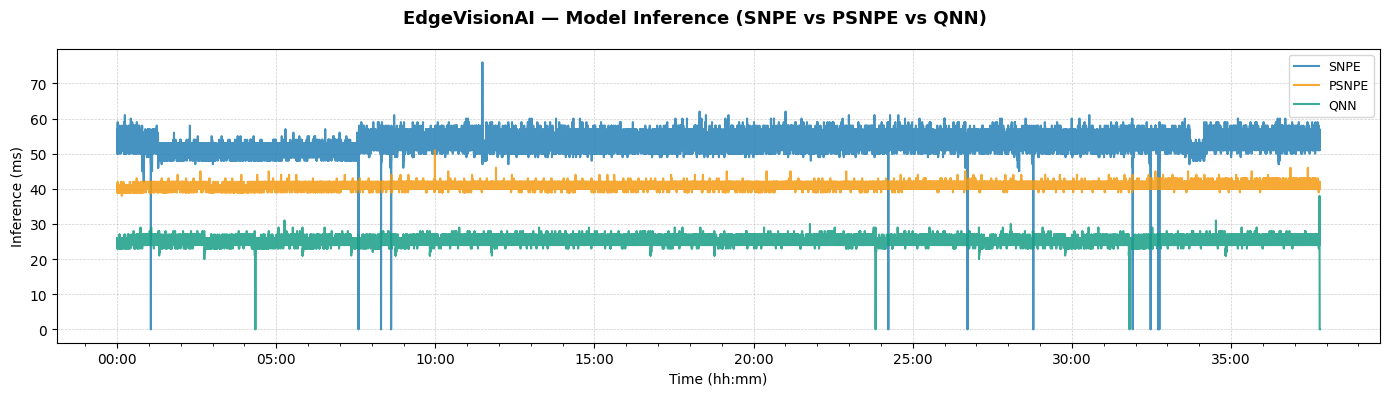

Saved → plots/time_series_inference_ms.png


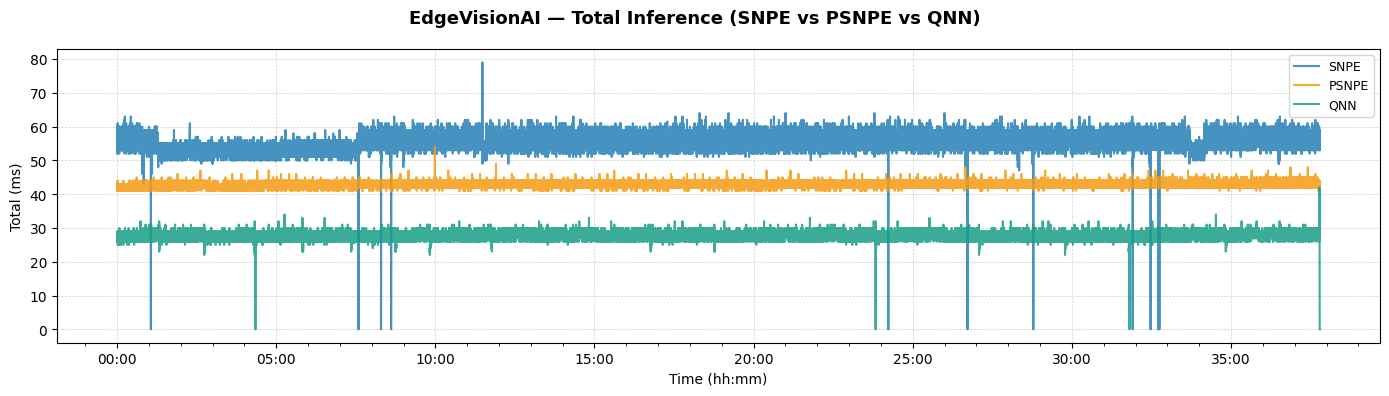

Saved → plots/time_series_total_ms.png


In [5]:
PLOT_CONFIG = [
    {"column": "cpu_pct",      "title": "CPU Usage",        "ylabel": "CPU (%)"},
    {"column": "memory_mb",    "title": "Memory Usage",     "ylabel": "Memory (MB)"},
    {"column": "fps",          "title": "FPS",              "ylabel": "Frames per Second"},
    {"column": "inference_ms", "title": "Model Inference",  "ylabel": "Inference (ms)"},
    {"column": "total_ms",     "title": "Total Inference",  "ylabel": "Total (ms)"},
]

FIGURE_HEIGHT = 4

# Ordered framework names so the legend is always consistent
framework_order = [name for name in ("SNPE", "PSNPE", "QNN") if name in aligned]

def _fmt_hhmm(x, _):
    x = max(0, int(x))
    return f"{x // 3600:02d}:{(x % 3600) // 60:02d}"
hhmm_formatter = ticker.FuncFormatter(_fmt_hhmm)

for cfg in PLOT_CONFIG:
    col = cfg["column"]

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
    fig.suptitle(
        f"EdgeVisionAI — {cfg['title']} (SNPE vs PSNPE vs QNN)",
        fontsize=13, fontweight="bold",
    )

    for name in framework_order:
        series = aligned[name][col]
        ax.plot(
            relative_seconds,
            series.values,
            label=name,
            color=COLORS[name],
            linewidth=LINE_WIDTH,
            alpha=ALPHA,
        )

    ax.set_xlabel("Time (hh:mm)")
    ax.set_ylabel(cfg["ylabel"])
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(18000))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(3600))
    ax.xaxis.set_major_formatter(hhmm_formatter)

    fig.tight_layout()
    out_file = f"plots/time_series_{col}.png"
    plt.savefig(out_file, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_file}")

## 6. Summary Statistics

In [6]:
for metric_cfg in PLOT_CONFIG:
    col = metric_cfg["column"]
    rows = []
    for name in framework_order:
        s = aligned[name][col].dropna()
        rows.append({
            "Framework": name,
            "Mean": round(s.mean(), 2),
            "Median": round(s.median(), 2),
            "Min": round(s.min(), 2),
            "Max": round(s.max(), 2),
            "Std": round(s.std(), 2),
        })
    summary = pd.DataFrame(rows).set_index("Framework")
    print(f"\n### {metric_cfg['title']} ({col})")
    display(summary)


### CPU Usage (cpu_pct)


,Mean,Median,Min,Max,Std
Framework,,,,,
SNPE,14.05,14.13,0.24,15.48,0.56
PSNPE,14.46,14.37,12.97,15.78,0.39
QNN,10.69,10.64,0.36,12.41,0.56



### Memory Usage (memory_mb)


,Mean,Median,Min,Max,Std
Framework,,,,,
SNPE,353.86,355.46,278.67,409.79,26.84
PSNPE,590.19,585.21,282.87,900.36,164.18
QNN,254.60,254.09,119.75,310.99,18.34



### FPS (fps)


,Mean,Median,Min,Max,Std
Framework,,,,,
SNPE,17.57,17.50,0.00,52.22,0.60
PSNPE,22.30,22.22,19.17,65.91,0.34
QNN,30.04,30.32,0.00,113.55,0.98



### Model Inference (inference_ms)


,Mean,Median,Min,Max,Std
Framework,,,,,
SNPE,53.00,53.0,0.0,76.0,1.92
PSNPE,40.78,41.0,38.0,51.0,0.62
QNN,25.19,25.0,0.0,38.0,0.91



### Total Inference (total_ms)


,Mean,Median,Min,Max,Std
Framework,,,,,
SNPE,55.33,55.0,0.0,79.0,2.01
PSNPE,42.79,43.0,41.0,54.0,0.63
QNN,27.72,28.0,0.0,42.0,1.00
